In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
from scipy import signal
from statsmodels.tsa import tsatools, seasonal
from collections import defaultdict
import os, sys
from tqdm import tqdm
from typing import Literal
from meegkit.detrend import detrend as meeg_detrend, regress

import matplotlib.pyplot as plt

In [ ]:
os.chdir(r'J:\Onderzoek\21-763_rvanes_MiniECG-2-Data\E_ResearchData\2_ResearchData\numpy\numpy')

In [255]:
def DeTrender(ts: np.ndarray,
              how: Literal=['poly', 'MSTL', 'meeg'],
              order=1, 
              period=100, 
              windows=101, 
              cutsize=250,
              median_window=25,
              iterate=5):
    if how == 'poly':
        return tsatools.detrend(ts, order=order)
    elif how == 'MSTL':
        detrender= seasonal.MSTL(ts, periods=period, windows=windows, iterate=iterate).fit()
        return detrender.seasonal
    elif how == 'meeg':
        '''
         Use sinusoids as basis functions:
          This will suffer from the Gibbs-phenomenon. 
          To mitigate this, we have to cut the head/tail
        '''
        _ts = np.array(ts).astype(float)
        return meeg_detrend(_ts, order=order, basis="sinusoids")[0][cutsize:-cutsize] 
    elif how == 'sliding_median':
        '''
         Make base plot using sliding mean, subtract from raw 
        '''
        sl= np.median(np.lib.stride_tricks.sliding_window_view(ts, (median_window,)), axis=1)
        return ts[median_window-1:] - sl
    else:
        raise ValueError(f"For now we only accept ['poly', 'MSTL', 'meeg]")

In [ ]:
# LOAD IN ALL THE NPYs
DIRS = os.listdir('.')
ECG_DICT = defaultdict(list)
SKIPPED = []
for DIR in tqdm(DIRS):
    for FILE in os.listdir(DIR):
        if FILE.endswith('.npy'):
            arr = np.load(os.path.join(DIR, FILE))
            vars = np.var(arr, axis=1)
            if any(vars == 0) == False:
                ECG_DICT[DIR].append(arr)
            else:
                SKIPPED.append(f"{DIR}/{FILE}")

In [ ]:
c = 0
for k,v in ECG_DICT.items():
    c += len(v)
print(f"We kept {c} ECG results, skipping {len(SKIPPED)} because they had at least one flat band")

# Get Spectrograms

In [214]:
ECG_DICT.keys()

dict_keys(['20210921', '20211117', '20211118', '20211119', '20211123', '20211124', '20211125', '20211126', '20211129', '20211130', '20211201', '20211202', '20211206', '20211207', '20211208', '20211209', '20211210', '20211213', '20211214', '20211216', '20211220', '20211221', '20211224', '20211227', '20220105', '20220107', '20220113', '20220117', '20220124', '20220131', '20220201', '20220208', '20220209', '20220210', '20220212', '20220214', '20220215', '20220216', '20220218', '20220301', '20220302', '20220303', '20220305', '20220306', '20220307', '20220308', '20220311', '20220312', '20220314', '20220315', '20220316', '20220317', '20220318', '20220321', '20220322', '20220323', '20220324', '20220325', '20220328', '20220329', '20220330', '20220331', '20220401', '20220402', '20220403', '20220404', '20220405', '20220406', '20220407', '20220408', '20220409', '20220412', '20220413', '20220415', '20220416', '20220417', '20220418', '20220419', '20220420', '20220421', '20220422', '20220423', '2022

In [234]:
raw = ECG_DICT['20230807'][1][1,:]

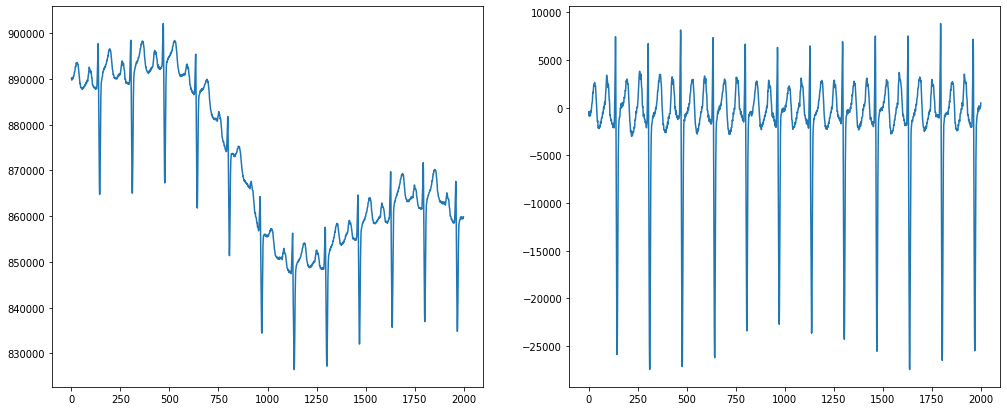

In [247]:
d=DeTrender(raw, how='meeg', order=24, period=250, cutsize=250)
_, ax = plt.subplots(ncols=2, figsize=(17,7))
ax[0].plot(raw[250:-250])
ax[1].plot(d)


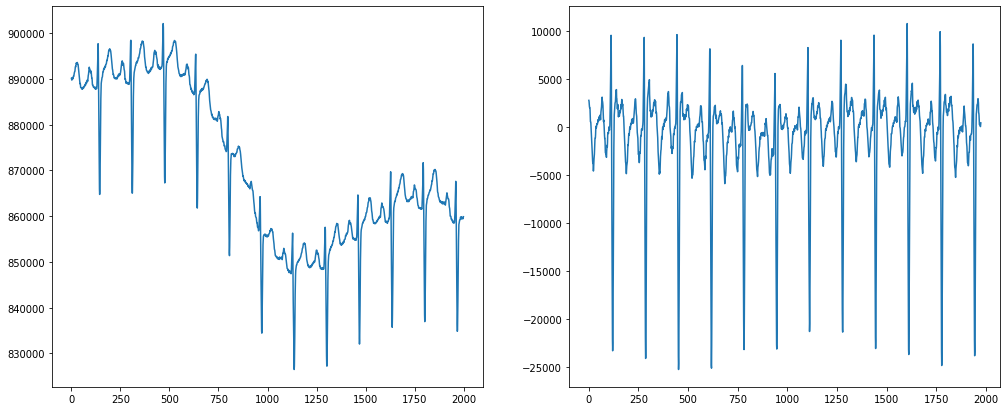

In [256]:
d=DeTrender(raw, how='sliding_median', order=24, period=250)
_, ax = plt.subplots(ncols=2, figsize=(17,7))
ax[0].plot(raw[250:-250])
ax[1].plot(d[250:-250])

# Fourier coefficients

# Peak/valley characteristics